# Task 3: Collaborative Filtering for Recommendation

**Course:** 504048 - Mining Massive Data Sets  
**Description:**  
This notebook implements a **User-User Collaborative Filtering** algorithm for rating prediction.  
To find similar users efficiently in O(1) average time, we use **Locality Sensitive Hashing (LSH)**  
with random hyperplane projections, which approximates cosine similarity on mean-centred rating vectors.

**Key design choices:**
- **Similarity metric:** Pearson correlation on co-rated items only (zeros = unrated, not dislike)  
- **Fast candidate retrieval:** LSH bucket lookup - O(1) average vs. O(M) brute-force scan  
- **Rating prediction:** Weighted average of neighbour ratings, weighted by Pearson similarity  

---

## 0. Setup & Imports

In [ ]:
!pip install pyspark -q


In [ ]:
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('Task3-CollaborativeFiltering') \
    .master('local[*]') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession started:', spark.version)


## 1. Chart Styling

A shared dark-theme palette and a helper that applies it to any Matplotlib figure/axes.

In [ ]:
# -- Dark-theme colour tokens -----------------------------------------------
PALETTE = {
    'bg':      '#0d1117',   # figure background
    'surface': '#161b22',   # axes background
    'border':  '#30363d',   # spine / grid colour
    'lsh':     '#58a6ff',   # LSH series
    'brute':   '#f78166',   # brute-force series
    'text':    '#e6edf3',   # primary text
    'text2':   '#c9d1d9',   # secondary text / tick labels
}


def apply_dark_style(fig, axes=None):
    """
    Apply the project dark theme to *fig* and optionally to one or more *axes*.

    Parameters
    ----------
    fig   : matplotlib.figure.Figure
    axes  : Axes or iterable of Axes, optional
    """
    fig.patch.set_facecolor(PALETTE['bg'])
    ax_list = (
        axes if hasattr(axes, '__iter__') else
        [axes] if axes is not None else
        []
    )
    for ax in ax_list:
        ax.set_facecolor(PALETTE['surface'])
        ax.tick_params(colors=PALETTE['text2'], labelsize=9)
        ax.xaxis.label.set_color(PALETTE['text2'])
        ax.yaxis.label.set_color(PALETTE['text2'])
        ax.title.set_color(PALETTE['text'])
        for spine in ax.spines.values():
            spine.set_edgecolor(PALETTE['border'])

## 2. Data & Similarity

### `Dataset`
Reads `ratings**k.csv` (columns: `user`, `item`, `rating`) and builds two lookup tables:
- `user_items[u]` -> `{item: rating, ...}` - all items rated by user *u*  
- `item_users[i]` -> `{user: rating, ...}` - all users who rated item *i*

### `Similarity`
Static methods for user-similarity metrics.  
**Pearson correlation on co-rated items** is used so that a rating of 0  
(meaning "not yet rated") is excluded from the similarity computation -  
it does *not* imply the user dislikes the item.

In [ ]:
class Dataset:
    """
    Loads a user-item rating dataset and provides fast per-user and
    per-item look-ups.

    Parameters
    ----------
    source : str or pd.DataFrame
        Path to a CSV file **or** an already-loaded DataFrame.
        The CSV/DataFrame must contain columns: user, item, rating.
    """

    def __init__(self, source, spark=None):
        if spark and isinstance(source, str):
            self.df = spark.read.csv(source, header=True, inferSchema=True).toPandas()
        else:
            self.df = source if isinstance(source, pd.DataFrame) else pd.read_csv(source)
        # user  -> {item: rating}
        self.user_items: dict[str, dict] = defaultdict(dict)
        # item  -> {user: rating}
        self.item_users: dict[str, dict] = defaultdict(dict)
        self._build_index()

    def _build_index(self):
        """Populate user_items and item_users from the raw DataFrame."""
        for user, item, rating in zip(
            self.df['user'], self.df['item'], self.df['rating']
        ):
            self.user_items[user][item] = rating
            self.item_users[item][user] = rating

    def __len__(self):
        return len(self.user_items)


class Similarity:
    """
    Collection of user-user similarity metrics.

    All methods accept two rating dictionaries {item: rating} and return
    a scalar similarity in [-1, 1].
    """

    @staticmethod
    def pearson(ratings_u: dict, ratings_v: dict) -> float:
        """
        Pearson correlation computed **only over co-rated items**.

        A rating value of 0 means the item has not been rated yet -
        it is **not** treated as a negative signal.

        Returns 0.0 when the two users share no co-rated items or
        when one of them has zero variance on the shared items.
        """
        common_items = list(set(ratings_u) & set(ratings_v))
        if not common_items:
            return 0.0

        r_u = np.array([ratings_u[i] for i in common_items], dtype=float)
        r_v = np.array([ratings_v[i] for i in common_items], dtype=float)

        # Mean-centre each vector
        r_u -= r_u.mean()
        r_v -= r_v.mean()

        denominator = np.linalg.norm(r_u) * np.linalg.norm(r_v)
        return float(np.dot(r_u, r_v) / denominator) if denominator else 0.0

## 3. Algorithm: LSH Index + Collaborative Filtering

### `LSHIndex` - O(1) candidate retrieval

Uses **random hyperplane projection** (sign-based) which approximates  
cosine similarity on mean-centred rating vectors.

Each user is hashed into `L` buckets (one per hash table).  
Candidate lookup is **O(1) average**: hash the query user -> read every bucket.

### `CollaborativeFiltering`

Wraps an `LSHIndex` and a `Similarity` metric into a complete CF pipeline:
1. Index all training users with LSH.  
2. For a (user, item) query, retrieve candidates via LSH (or brute-force).  
3. Rank candidates by similarity, keep the top-N.  
4. Predict the rating as a similarity-weighted average.

In [ ]:
class LSHIndex:
    """
    Locality Sensitive Hashing index for fast user-user similarity search.

    Each user's rating vector is projected onto K random hyperplanes per table
    (L tables total).  Users that land in the same bucket are returned as
    candidates without scanning the entire user base.

    Parameters
    ----------
    n_items    : int   - number of distinct items (vector dimension)
    item_index : dict  - mapping item_id -> column index
    K          : int   - hyperplanes per table (hash bits); controls precision
    L          : int   - independent hash tables; controls recall
    seed       : int   - random seed for reproducibility
    """

    def __init__(
        self,
        n_items: int,
        item_index: dict,
        K: int = 8,
        L: int = 10,
        seed: int = 42,
    ):
        self.K = K
        self.L = L
        self.n_items    = n_items
        self.item_index = item_index

        rng = np.random.default_rng(seed)
        # Shape: (L, K, n_items) - L tables, each with K random hyperplanes
        self.planes = rng.standard_normal((L, K, n_items))
        # L hash tables: hash_key (tuple of K bits) -> list of user IDs
        self.tables: list[dict] = [defaultdict(list) for _ in range(L)]

    # ------------------------------------------------------------------ #
    #  Internal helpers
    # ------------------------------------------------------------------ #

    def _vectorize(self, user_ratings: dict) -> np.ndarray:
        """Convert {item: rating} to a dense, mean-centred rating vector."""
        vec = np.zeros(self.n_items)
        for item, rating in user_ratings.items():
            if item in self.item_index:
                vec[self.item_index[item]] = rating
        # Mean-centre over rated items only (unrated positions stay at 0)
        rated_mask = vec != 0
        if rated_mask.any():
            vec[rated_mask] -= vec[rated_mask].mean()
        return vec

    def _hash(self, vec: np.ndarray, table_idx: int) -> tuple:
        """Project *vec* onto K hyperplanes; return the sign-bit tuple."""
        projections = self.planes[table_idx] @ vec  # shape (K,)
        return tuple((projections >= 0).astype(int))

    # ------------------------------------------------------------------ #
    #  Public interface
    # ------------------------------------------------------------------ #

    def index(self, user_items: dict) -> None:
        """
        Build the index from all users.  Complexity: O(M · L · K · n_items).

        Parameters
        ----------
        user_items : {user_id: {item_id: rating}} mapping for all users.
        """
        for user, ratings in user_items.items():
            vec = self._vectorize(ratings)
            for t in range(self.L):
                key = self._hash(vec, t)
                self.tables[t][key].append(user)

    def query(self, user: str, user_items: dict) -> set:
        """
        Return the set of candidate neighbours for *user*.

        Collects all users sharing any bucket with the query user across
        all L tables, then removes the query user itself.
        Average complexity: O(1) - independent of dataset size.
        """
        vec = self._vectorize(user_items[user])
        candidates: set = set()
        for t in range(self.L):
            key = self._hash(vec, t)
            candidates.update(self.tables[t][key])
        candidates.discard(user)
        return candidates


class CollaborativeFiltering:
    """
    User-User Collaborative Filtering with LSH-based O(1) candidate retrieval.

    Parameters
    ----------
    dataset : Dataset
    sc      : SparkContext, optional - enables distributed similarity computation
    sim_fn  : callable - similarity function, default Similarity.pearson
    K       : int      - LSH hyperplanes per table
    L       : int      - LSH hash tables
    cache   : bool     - cache computed similarity scores to avoid recomputation
    """

    def __init__(
        self,
        dataset: Dataset,
        sc=None,
        sim_fn=Similarity.pearson,
        K: int = 8,
        L: int = 10,
        cache: bool = True,
    ):
        self.sc         = sc
        self.sim_fn     = sim_fn
        self.user_items = dataset.user_items
        self.item_users = dataset.item_users
        self.cache      = cache
        self._sim_cache: dict = {}

        # Build LSH index over all training users
        all_items       = list(dataset.item_users.keys())
        self.item_index = {item: idx for idx, item in enumerate(all_items)}
        self.lsh        = LSHIndex(len(all_items), self.item_index, K=K, L=L)
        self.lsh.index(self.user_items)

    # ------------------------------------------------------------------ #
    #  Similarity
    # ------------------------------------------------------------------ #

    def similarity(self, u1: str, u2: str) -> float:
        """
        Compute (and optionally cache) the similarity between two users.

        Cache key is the sorted pair so that sim(a,b) == sim(b,a).
        """
        if not self.cache:
            return self.sim_fn(self.user_items[u1], self.user_items[u2])
        key = (min(u1, u2), max(u1, u2))
        if key not in self._sim_cache:
            self._sim_cache[key] = self.sim_fn(
                self.user_items[u1], self.user_items[u2]
            )
        return self._sim_cache[key]

    # ------------------------------------------------------------------ #
    #  Candidate retrieval (LSH vs. brute force)
    # ------------------------------------------------------------------ #

    def get_candidates(self, user: str) -> set:
        """O(1) average: LSH bucket lookup."""
        return self.lsh.query(user, self.user_items)

    def get_candidates_brute(self, user: str) -> set:
        """O(M): enumerate the entire user base."""
        candidates = set(self.user_items.keys())
        candidates.discard(user)
        return candidates

    # ------------------------------------------------------------------ #
    #  Prediction
    # ------------------------------------------------------------------ #

    def _compute_similarities(self, user: str, candidates) -> list:
        """
        Compute similarity scores between `user` and every candidate
        in parallel using an RDD map.  Falls back to a plain list
        comprehension when no SparkContext is available.

        Returns a list of (candidate_id, similarity) tuples.
        """
        if self.sc is not None:
            return (
                self.sc.parallelize(list(candidates))
                       .map(lambda u: (u, self.similarity(user, u)))
                       .collect()
            )
        return [(c, self.similarity(user, c)) for c in candidates]

    def top_neighbors(self, user: str, N: int = 10) -> list:
        """
        Return the top-N most similar users found by the current candidate
        retrieval strategy (LSH by default).

        Returns a list of (user_id, similarity) tuples, sorted descending.
        """
        scored = self._compute_similarities(user, self.get_candidates(user))
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:N]

    def predict(self, user: str, item: str, N: int = 10) -> float:
        """
        Predict user *u*'s rating for *item* using the top-N neighbours.

        If none of the neighbours has rated *item*, falls back to the
        user's own mean rating (or 0.0 if the user has no ratings).
        """
        neighbors = self.top_neighbors(user, N)
        # Keep only neighbours who have actually rated the target item
        raters = [
            (nbr, sim)
            for nbr, sim in neighbors
            if item in self.user_items[nbr]
        ]

        if not raters:
            # Cold-start fallback: user's own mean
            own_ratings = list(self.user_items[user].values())
            return float(np.mean(own_ratings)) if own_ratings else 0.0

        # Weighted average: sum(sim * rating) / sum(|sim|)
        numerator   = sum(sim * self.user_items[nbr][item] for nbr, sim in raters)
        denominator = sum(abs(sim) for _, sim in raters)
        return numerator / denominator if denominator != 0 else 0.0

## 4. Experiments

### `Experiment`

Encapsulates all experimental logic as a single, configuration-driven class:
- **`run(use_lsh, K, L)`** - evaluate RMSE and wall-clock time for each N in `N_values`  
- **`benchmark_scaling(full_df, user_counts)`** - measure lookup latency as dataset grows  
- **`plot_rmse()` / `plot_runtime()`** - grouped-bar charts comparing LSH vs. brute force  
- **`plot_scaling(bench_df)`** - line chart showing lookup latency vs. dataset size

In [ ]:
class Experiment:
    """
    RMSE and runtime experiments for Collaborative Filtering.

    Parameters
    ----------
    train_df : pd.DataFrame - training split
    test_df  : pd.DataFrame - test split
    N_values : list[int]   - neighbour counts to evaluate
    cache    : bool        - whether to cache similarity scores
    """

    def __init__(
        self,
        train_df: pd.DataFrame,
        test_df:  pd.DataFrame,
        N_values: list = None,
        cache:    bool = True,
    ):
        self.train_ds = Dataset(train_df)
        self.test_df  = test_df
        self.N_values = list(N_values) if N_values is not None else [5, 10, 20, 30]
        self.cache    = cache
        self.results: list[dict] = []

    # ------------------------------------------------------------------ #
    #  Internal helpers
    # ------------------------------------------------------------------ #

    @staticmethod
    def _rmse(predictions: list, actuals: list) -> float:
        """Root Mean Squared Error."""
        return float(
            np.sqrt(np.mean((np.array(predictions) - np.array(actuals)) ** 2))
        )

    def _evaluate(self, cf: CollaborativeFiltering, N: int) -> float:
        """Run CF predictions over the test set and return RMSE."""
        predictions, actuals = [], []
        for row in self.test_df.itertuples():
            predictions.append(cf.predict(row.user, row.item, N))
            actuals.append(row.rating)
        return self._rmse(predictions, actuals)

    # ------------------------------------------------------------------ #
    #  RMSE + runtime experiment
    # ------------------------------------------------------------------ #

    def run(
        self,
        use_lsh: bool = True,
        K: int = 8,
        L: int = 10,
    ) -> None:
        """
        Evaluate the CF model for every N in self.N_values.

        Results (N, method, RMSE, wall-clock time) are appended to
        self.results so multiple calls can be compared in one chart.

        Parameters
        ----------
        use_lsh : bool - use LSH (True) or brute-force scan (False)
        K, L    : int  - LSH hyperplane / table counts
        """
        label = 'LSH  O(1)' if use_lsh else 'Brute O(N)'
        cf    = CollaborativeFiltering(self.train_ds, sc=spark.sparkContext if spark else None, cache=self.cache, K=K, L=L)
        if not use_lsh:
            # Monkey-patch the candidate method for the brute-force baseline
            cf.get_candidates = cf.get_candidates_brute

        for N in self.N_values:
            t0      = time.perf_counter()
            rmse    = self._evaluate(cf, N)
            elapsed = time.perf_counter() - t0
            self.results.append({'N': N, 'method': label, 'RMSE': rmse, 'time': elapsed})
            print(f'  [{label}]  N={N:>3d}  RMSE={rmse:.4f}  t={elapsed:.3f}s')

    # ------------------------------------------------------------------ #
    #  Scaling benchmark
    # ------------------------------------------------------------------ #

    def benchmark_scaling(
        self,
        full_df: pd.DataFrame,
        user_counts: list = None,
        repeats: int = 40,
        sc=None,
    ) -> pd.DataFrame:
        """
        Measure average candidate-retrieval latency (ms) as dataset grows.

        Parameters
        ----------
        full_df     : pd.DataFrame - full ratings dataset
        user_counts : list[int]   - dataset sizes to benchmark
        repeats     : int         - timing repetitions per configuration

        Returns
        -------
        pd.DataFrame with columns: users, method, ms
        """
        if user_counts is None:
            user_counts = [200, 500, 1000, 1500, 2000]

        rows = []
        for n in user_counts:
            # Sub-sample the first *n* unique users
            sub_users = set(full_df['user'].unique()[:n])
            sub_df    = full_df[full_df['user'].isin(sub_users)]
            ds        = Dataset(sub_df)
            cf        = CollaborativeFiltering(ds, sc=sc, cache=False)
            probe     = list(ds.user_items.keys())[0]

            for label, fn in [
                ('LSH  O(1)',   cf.get_candidates),
                ('Brute O(N)', cf.get_candidates_brute),
            ]:
                times = []
                for _ in range(repeats):
                    t0 = time.perf_counter()
                    fn(probe)
                    times.append(time.perf_counter() - t0)
                rows.append({'users': n, 'method': label, 'ms': np.mean(times) * 1_000})

        return pd.DataFrame(rows)

    # ------------------------------------------------------------------ #
    #  Plotting helpers
    # ------------------------------------------------------------------ #

    def _grouped_bar_chart(self, y_col: str, ylabel: str, title: str, fmt: str):
        """
        Generic grouped-bar chart over self.results.

        Parameters
        ----------
        y_col  : column in results to plot on y-axis
        ylabel : y-axis label
        title  : chart title
        fmt    : bar-label format string (e.g. '{:.3f}')
        """
        df      = pd.DataFrame(self.results)
        methods = list(df['method'].unique())
        xs      = sorted(df['N'].unique())
        n_m     = len(methods)
        bar_w   = 0.32
        colors  = [PALETTE['lsh'], PALETTE['brute']]
        offsets = [(i - (n_m - 1) / 2) * bar_w for i in range(n_m)]

        fig, ax = plt.subplots(figsize=(11, 5))
        apply_dark_style(fig, ax)

        for i, (method, color) in enumerate(zip(methods, colors)):
            sub  = df[df['method'] == method].set_index('N')
            vals = [float(sub.loc[n, y_col]) if n in sub.index else 0.0 for n in xs]
            peak = max(vals) if vals else 1
            bars = ax.bar(
                [x + offsets[i] for x in range(len(xs))],
                vals,
                width=bar_w * 0.92,
                color=color,
                alpha=0.85,
                label=method,
                zorder=3,
                linewidth=0,
            )
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + peak * 0.012,
                    fmt.format(v),
                    ha='center', va='bottom',
                    fontsize=7.5, color=PALETTE['text2'],
                )

        ax.set_xticks(range(len(xs)))
        ax.set_xticklabels([f'N = {n}' for n in xs])
        ax.set_xlabel('Number of neighbours  (N)', labelpad=8)
        ax.set_ylabel(ylabel, labelpad=8)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis='y', color=PALETTE['border'], linewidth=0.6, zorder=0)
        ax.grid(axis='y', which='minor', color=PALETTE['border'],
                linewidth=0.3, linestyle=':', zorder=0)
        ax.legend(framealpha=0.15, edgecolor=PALETTE['border'],
                  labelcolor=PALETTE['text2'], fontsize=9)
        plt.tight_layout()
        plt.show()

    def plot_rmse(self):
        """Bar chart: RMSE vs N, grouped by method."""
        self._grouped_bar_chart(
            'RMSE', 'RMSE',
            'Prediction Accuracy  -  RMSE by N',
            '{:.3f}',
        )

    def plot_runtime(self):
        """Bar chart: wall-clock time vs N, grouped by method."""
        self._grouped_bar_chart(
            'time', 'Wall-clock time  (s)',
            'Full-pass Runtime  -  by N',
            '{:.2f}s',
        )

    @staticmethod
    def plot_scaling(bench_df: pd.DataFrame) -> None:
        """Line chart: lookup latency (ms) vs dataset size."""
        fig, ax = plt.subplots(figsize=(11, 5))
        apply_dark_style(fig, ax)

        color_map = {
            'LSH  O(1)':   PALETTE['lsh'],
            'Brute O(N)':  PALETTE['brute'],
        }
        for method, grp in bench_df.groupby('method'):
            color = color_map.get(method, PALETTE['text2'])
            ax.plot(grp['users'], grp['ms'],
                    marker='o', linewidth=2.4, markersize=7,
                    color=color, label=method, zorder=4)
            ax.fill_between(grp['users'], grp['ms'], alpha=0.09, color=color)
            last = grp.iloc[-1]
            ax.annotate(
                f"{last['ms']:.3f} ms",
                xy=(last['users'], last['ms']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold',
            )

        ax.set_xlabel('Number of users in dataset', labelpad=8)
        ax.set_ylabel('Avg lookup time  (ms)', labelpad=8)
        ax.set_title(
            'Candidate Retrieval Scaling  -  LSH O(1) vs Brute O(N)',
            fontsize=13, fontweight='bold', pad=14,
        )
        ax.grid(color=PALETTE['border'], linewidth=0.5, zorder=0)
        ax.grid(which='minor', color=PALETTE['border'],
                linewidth=0.25, linestyle=':', zorder=0)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.legend(framealpha=0.15, edgecolor=PALETTE['border'],
                  labelcolor=PALETTE['text2'], fontsize=10)
        plt.tight_layout()
        plt.show()

## 5. Run Experiments on `ratings2k.csv`

1. Load the dataset and split 70 / 30 into train / test sets.  
2. Run the CF pipeline with **LSH (O(1))** candidate retrieval.  
3. Re-run with **brute-force (O(N))** candidate retrieval as a baseline.  
4. Plot RMSE and runtime side-by-side for both methods.

>> LSH O(1) candidate retrieval...
  [LSH  O(1)]  N=  5  RMSE=2.0283  t=0.587s
  [LSH  O(1)]  N= 10  RMSE=2.0691  t=0.701s
  [LSH  O(1)]  N= 20  RMSE=2.0691  t=0.698s
  [LSH  O(1)]  N= 30  RMSE=2.0691  t=0.684s

>> Brute-force O(N) candidate retrieval...
  [Brute O(N)]  N=  5  RMSE=1.1485  t=0.638s
  [Brute O(N)]  N= 10  RMSE=1.2426  t=0.338s
  [Brute O(N)]  N= 20  RMSE=1.2604  t=0.121s
  [Brute O(N)]  N= 30  RMSE=1.2724  t=0.111s


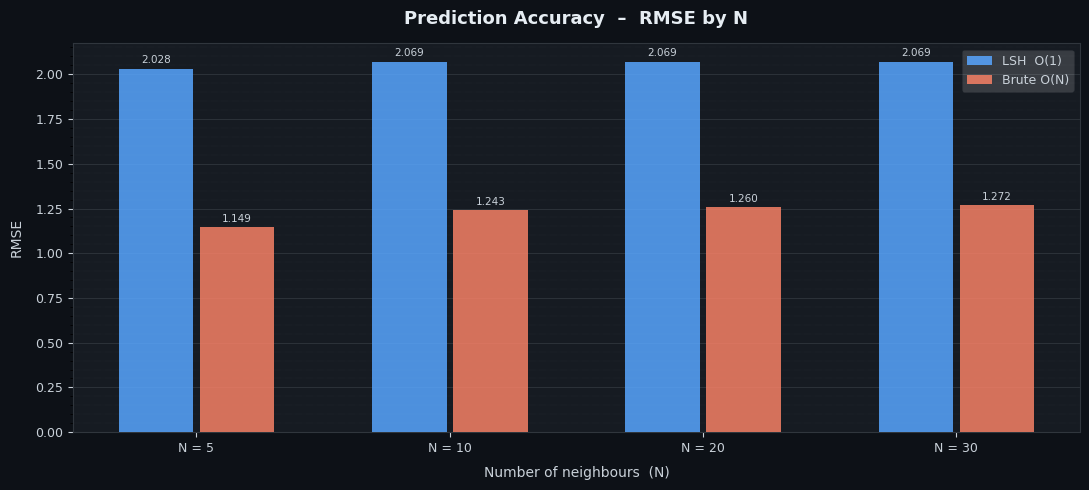

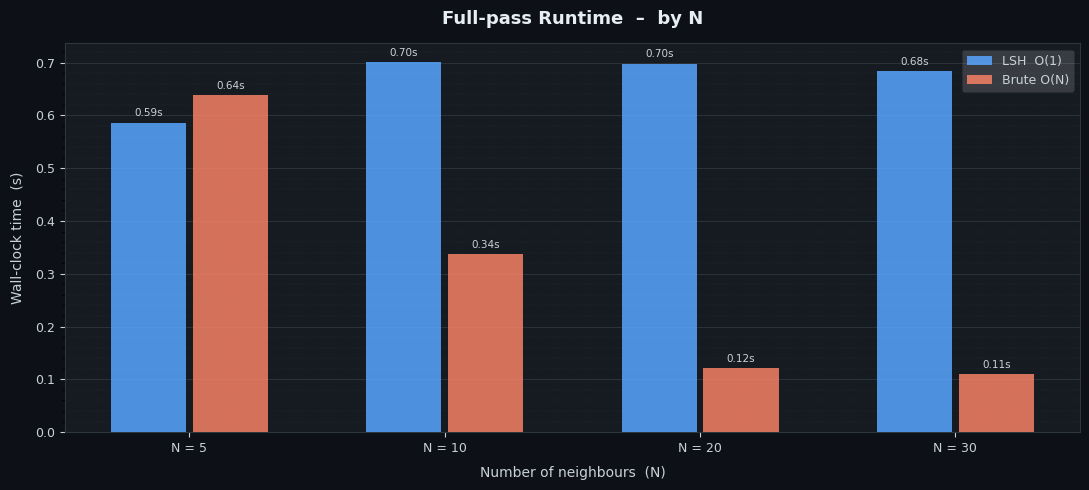

In [ ]:
# -- Load & split via Spark ------------------------------------------------
df2k = spark.read.csv('ratings2k.csv', header=True, inferSchema=True).toPandas()
train2k, test2k  = train_test_split(df2k, test_size=0.3, random_state=42)

# -- Experiment (N = 5, 10, 20, 30) ----------------------------------------
exp2k = Experiment(train2k, test2k, N_values=[5, 10, 20, 30], cache=True)

print('>> LSH O(1) candidate retrieval...')
exp2k.run(use_lsh=True)

print('\n>> Brute-force O(N) candidate retrieval...')
exp2k.run(use_lsh=False)

# -- Charts -----------------------------------------------------------------
exp2k.plot_rmse()
exp2k.plot_runtime()


## 6. Scaling Benchmark on `ratings20k.csv`

Measure how candidate-retrieval latency grows with dataset size for  
**LSH O(1)** vs **Brute O(N)**, sub-sampling 200 -> 2 000 users.

>> Benchmarking candidate-retrieval speed vs dataset size...
method  Brute O(N)  LSH  O(1)
users                        
200       0.004455   0.106133
500       0.012171   0.112235
1000      0.021329   0.125309
1500      0.039845   0.128120
2000      0.049266   0.128994


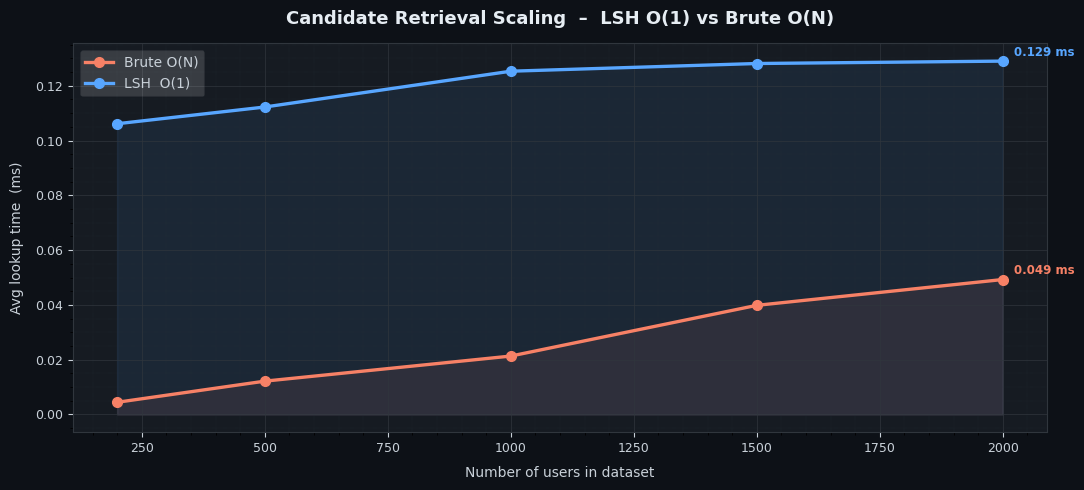

In [ ]:
# -- Load the larger dataset ------------------------------------------------
df20k = spark.read.csv('ratings20k.csv', header=True, inferSchema=True).toPandas()

# Experiment object only needs a dummy test set for the scaling benchmark
exp_scale = Experiment(df20k, df20k.head(1), N_values=[10], cache=False)

print('>> Benchmarking candidate-retrieval speed vs dataset size...')
bench = exp_scale.benchmark_scaling(
    full_df     = df20k,
    user_counts = [200, 500, 1000, 1500, 2000],
    repeats     = 40,
    sc          = spark.sparkContext,
)

# Pivot table for quick inspection
print(bench.pivot(index='users', columns='method', values='ms').to_string())

Experiment.plot_scaling(bench)